In [15]:
import numpy as np
import matplotlib.pyplot as pl
from scipy import integrate
from scipy import optimize
import finufft

In [2]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

## Frequency error vs time

In [3]:
def beta_calc(f0, M):
    """M in units of solar masses"""
    Mc = M*2e30
    return const*f0**(8/3)*Mc**(5/3)

def t_max_calc(f0, beta, f_max):
    temp0 = 0.375/beta
    temp1 = 1-(f0/f_max)**(8/3)
    return temp0*temp1

def freq_err(t, f0, M, delta_beta):
    """Error in the frequency from the dephasing
    M in units of solar masses
    """
    beta = beta_calc(f0, M)
    temp0 = (3*f0*delta_beta)/(5*beta*(1-8/3*beta*t)**(3/8))
    temp1 = 1+(-1+beta*t)/(1-8/3*beta*t)
    return temp0*temp1

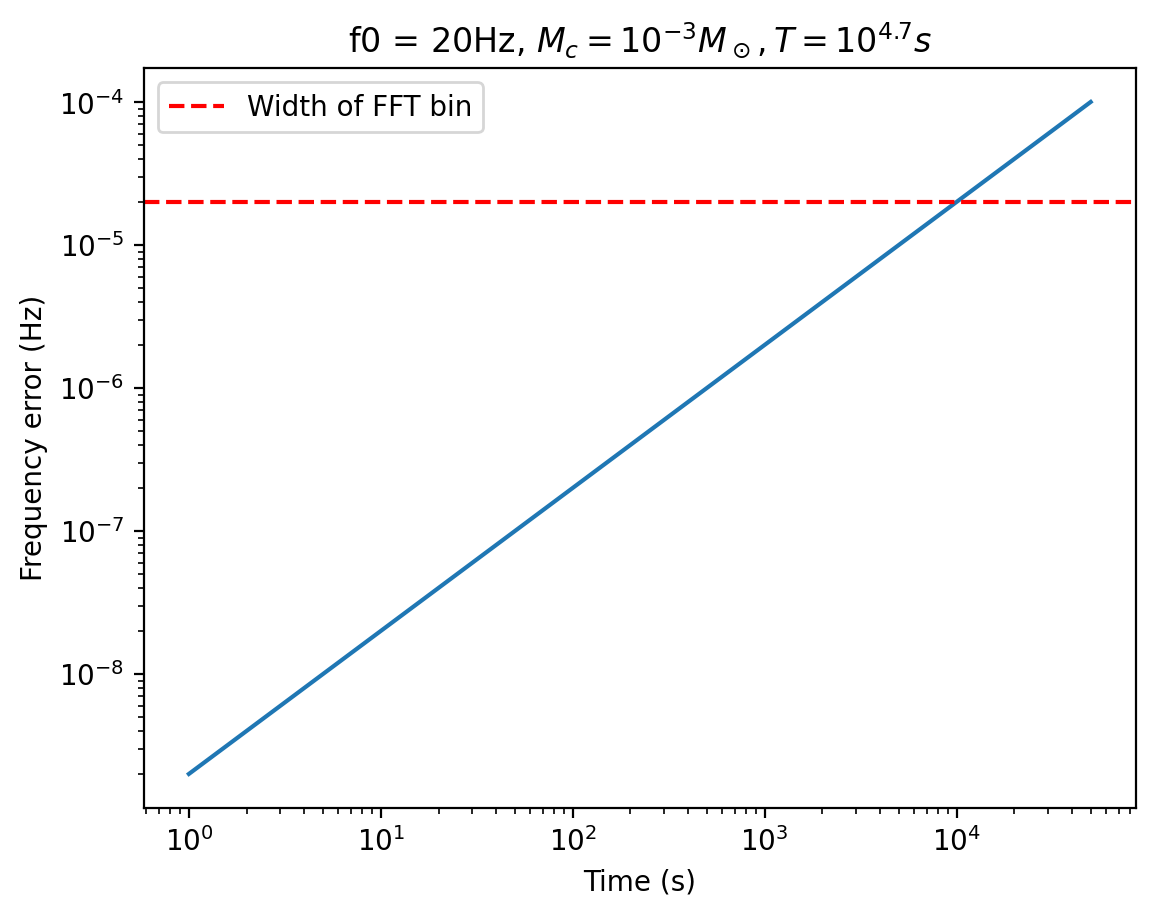

In [4]:
f0 = 20
M = 1e-3
beta = beta_calc(f0, M)
delta_beta = 1e-10

obs_duration = 5e4
T = min(obs_duration, t_max_calc(f0, beta, 200))

t_space = np.logspace(0, np.log10(T), 1000)
err_arr = abs(freq_err(t_space, f0, M, delta_beta))
pl.loglog(t_space, err_arr)
pl.axhline(1/T, c='r', ls='--', label="Width of FFT bin")
pl.legend()
pl.xlabel("Time (s)")
pl.ylabel("Frequency error (Hz)")
pl.title(r"f0 = %.0fHz, $M_c = 10^{%.0f} M_\odot, T = 10^{%.1f}s$" % 
         (f0, np.log10(M), np.log10(T)));

In [5]:
idx = np.argmin(abs(err_arr - 1/T))
crossover_t = t_space[idx]
crossover_t

np.float64(9956.865172378946)

In [6]:
phi = -6*pi/5*f0*(1-8./3.*beta*t_space)**(5/8)/beta

## Integrating to find lost power

In [8]:
def integrated_func_without_asd(t, f0, M):
    temp0 = np.power((1-8/3*beta_calc(f0, M)*t),-0.5)
    return temp0

def analytical_loss(offset, f0, M):
    temp_arr = []
    beta = beta_calc(f0, M)
    T = min(obs_duration, t_max_calc(f0, beta, 200))
    t_space = np.logspace(0, np.log10(T), 10000)
    for i in np.atleast_1d(offset):
        err_arr = abs(freq_err(t_space, f0, M, i))
        idx = np.argmin(abs(err_arr - 2/(T)))
        crossover_t = t_space[idx]

        temp0 = integrate.quad(integrated_func_without_asd, crossover_t, T, args = (f0, M))[0] 
        temp1 = integrate.quad(integrated_func_without_asd, 0, T, args = (f0, M))[0] 
        temp_arr.append(temp0/temp1)
    return np.array(temp_arr)

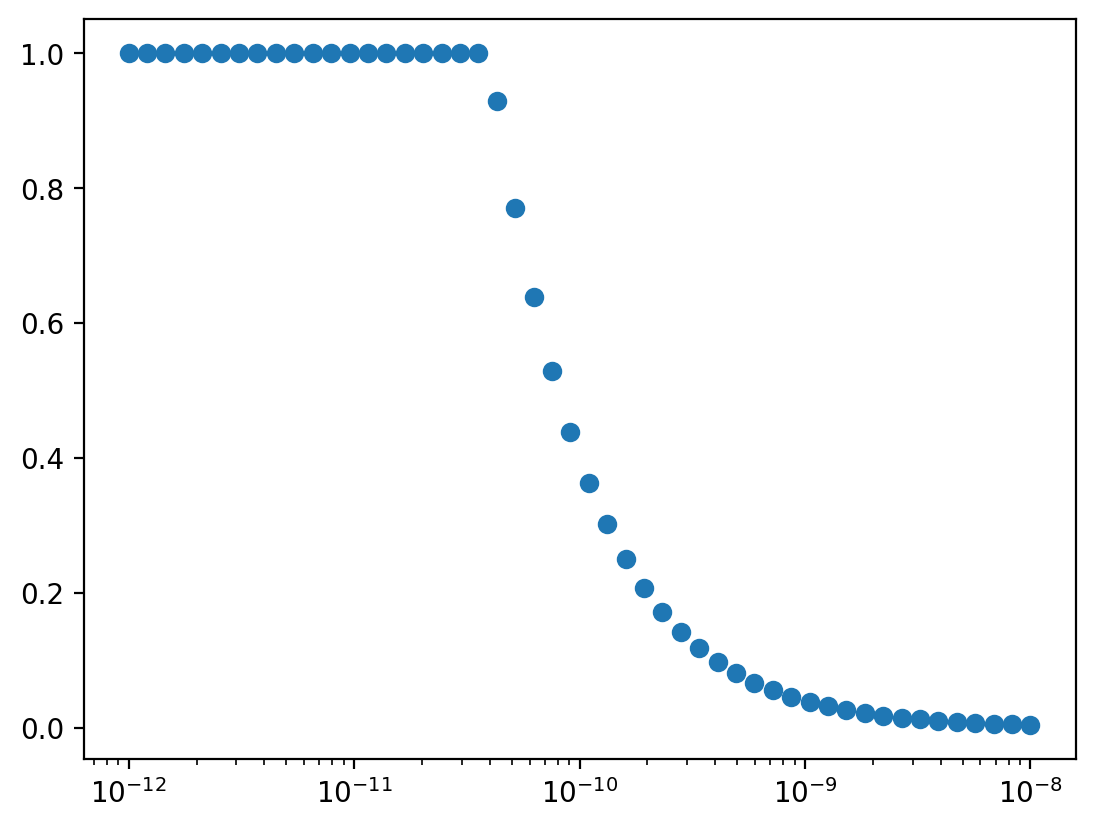

In [10]:
offset_arr = np.logspace(-12, -8, 50)
analytical_arr = analytical_loss(offset_arr, f0, M)
pl.semilogx(offset_arr, 1-analytical_arr, 'o')

## Numerical computation

In [53]:
class Resampler(object):
    """ Resample a timeseries and computes its FFT

    Example usage:

        TBD

    Attributes
    ----------
    TBD : 
    """
    def __init__(self, **kwws) -> None:
        # Convert to dictionaries when multiple detectors
        self.timeseries = None
        self.resampled_time = None
        self.freqs = None
        self.weights = None
    
    def nufft(self, normalized = False):
        signal = self.timeseries
        tau = self.resampled_time
        bin_no = len(tau) # make it an input
        
        scale = abs((2*np.pi) / (tau[-1] - tau[0]))
        tau_scaled = scale * (tau-tau[0]) - np.pi
        bins = np.arange(bin_no) - bin_no//2
        freqs = bins * scale
        
        weights = finufft.nufft1d1(tau_scaled, signal.astype(complex), bin_no)
        if normalized:
            weights /= len(signal) # normalizing for complex signal
        self.freqs = freqs
        self.weights = weights

    def nufft_real(self, normalized = False):
        signal = self.timeseries
        tau = self.resampled_time
        assert np.isrealobj(signal), "Timeseries is not real"

        scale = abs((2*np.pi) / (tau[-1] - tau[0]))
        tau_scaled = scale * (tau-tau[0]) - np.pi
        
        Nf = len(tau)//2
        N0 = Nf // 2
        bins = np.arange(Nf) # no negative frequencies
        freqs = bins * scale
        signal_shifted = signal * np.exp(1j * N0 * tau_scaled)

        weights = finufft.nufft1d1(tau_scaled, signal_shifted, Nf)
        if normalized:
            weights /= 0.5 * len(signal) # real signal so only 0.5 prefactor
        self.freqs = freqs
        self.weights = weights

    @property
    def power(self):
        return abs(self.weights)**2

In [84]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

f0 = 2**3
Mc = 3e-2* 2e30
f_max = 2**6
T_obs = 2**10
# pad_len = int(340*T_obs) #~0.01 added length to resampled data
beta = const*f0**(8/3)*Mc**(5/3)
f_signal = 4*f_max
nt = round(f_signal*T_obs)
t = (np.arange(nt)/f_signal)

phi = 6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta
tau = 6*pi/5*(1-8/3*beta*t)**(5/8)/beta
signal = np.real(1*np.exp(-1j*phi))

In [98]:
def phi_calc(beta, t=t, f0=f0):
    return 6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta

def phi_diff(beta, delta_beta, t=t, f0=f0):
    temp0 = 6*np.pi*f0*delta_beta*(-1+beta*t)/(5*beta**2*(1-8/3*beta*t)**(3/8))
    temp1 = 6*np.pi*f0*delta_beta / (5*beta**2)
    return temp0 + temp1

In [99]:
beta_relErr = 1
delta_beta = beta_relErr * beta

num_diff = phi_calc((1+beta_relErr)*beta) - phi_calc(beta)
ana_diff = phi_diff(beta, delta_beta)

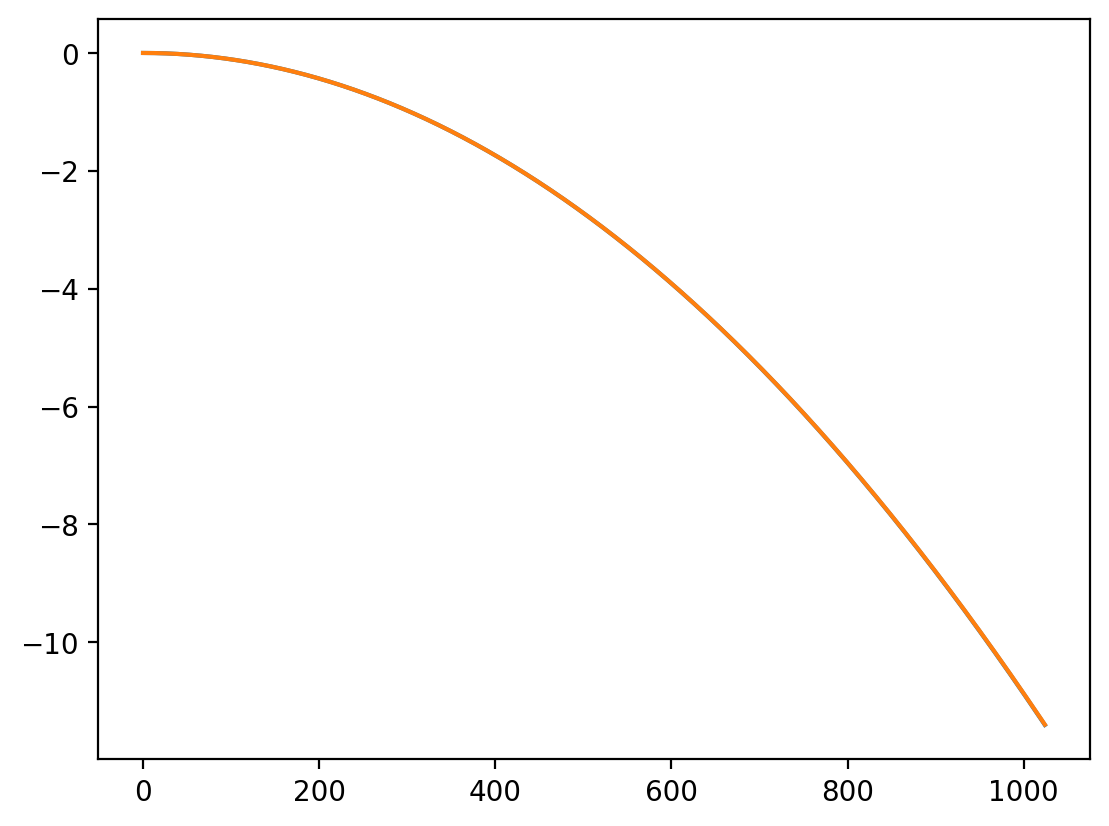

In [101]:
pl.plot(t, num_diff - num_diff[0])
pl.plot(t, ana_diff)

0.9613823178799339


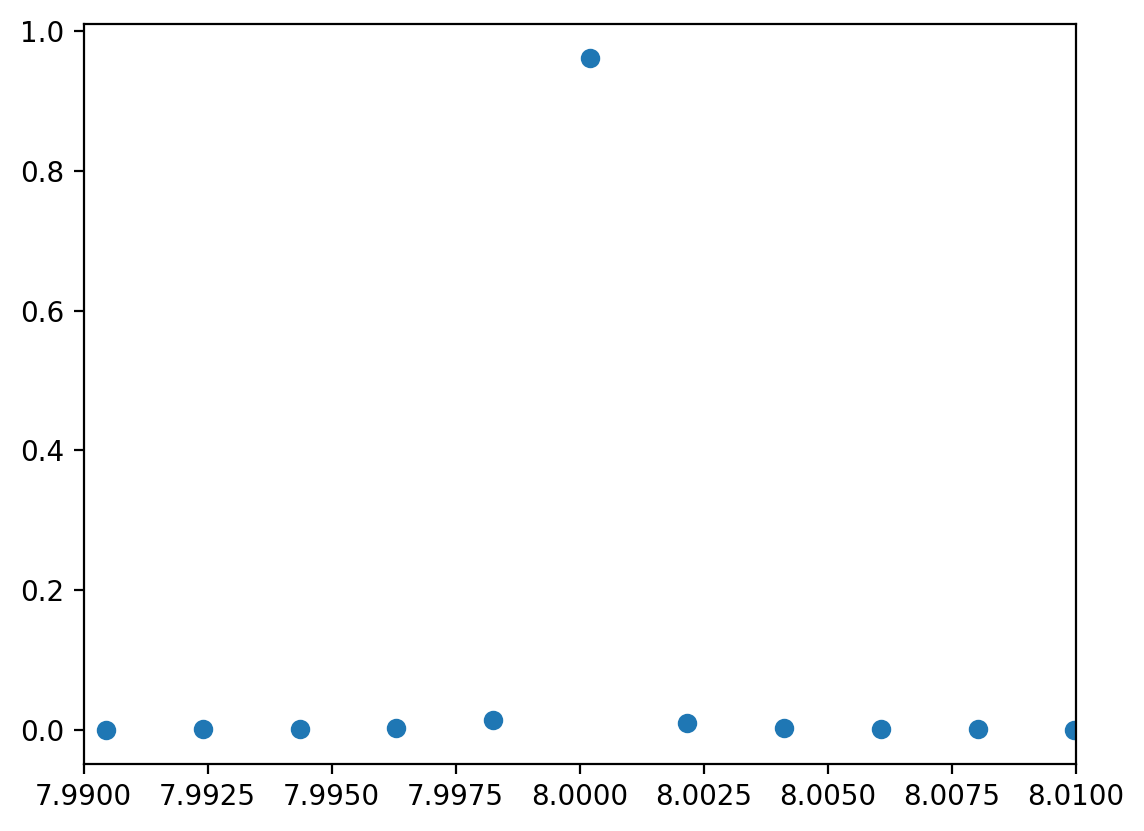

In [72]:
resampler = Resampler()
resampler.timeseries = signal
resampler.resampled_time = tau
resampler.nufft_real(normalized = True)
pl.plot(resampler.freqs, resampler.power, 'o')
pl.xlim(f0 - 0.01, f0 + 0.01)
print(max(resampler.power))

In [105]:
phi = 6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta
tau = 6*pi/5*(1-8/3*beta*t)**(5/8)/beta
signal = np.real(1*np.exp(-1j*phi))

err_arr = np.logspace(-3, 2, 100)
power_arr = []

for beta_relErr in err_arr:
    tau_wrong = 6*pi/5*(1-8/3*(1 + beta_relErr)*beta*t)**(5/8)/((1+beta_relErr) * beta)
    resampler = Resampler()
    resampler.timeseries = signal
    resampler.resampled_time = tau_wrong
    resampler.nufft_real(normalized = True)
    power_arr.append(max(resampler.power))

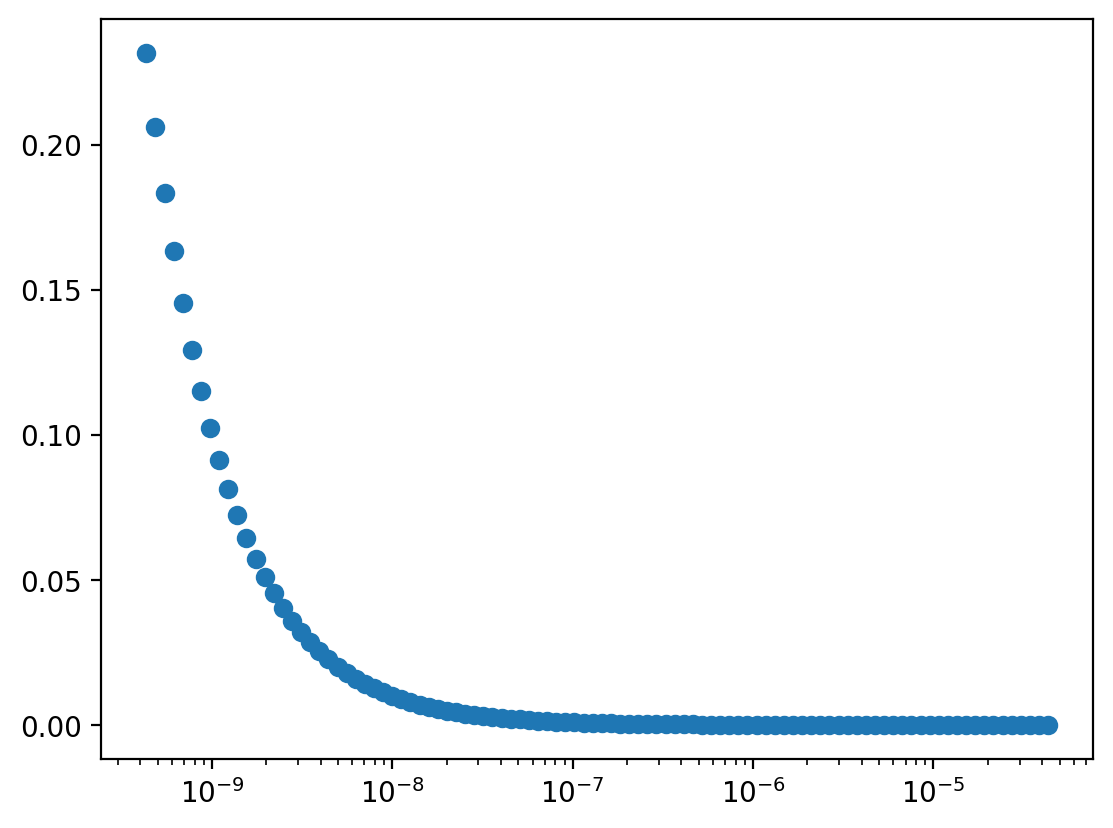

In [103]:
offset_arr = err_arr * beta
analytical_arr = analytical_loss(offset_arr, f0, M)
pl.semilogx(offset_arr, 1-analytical_arr, 'o')

Text(0, 0.5, 'Power recovery')

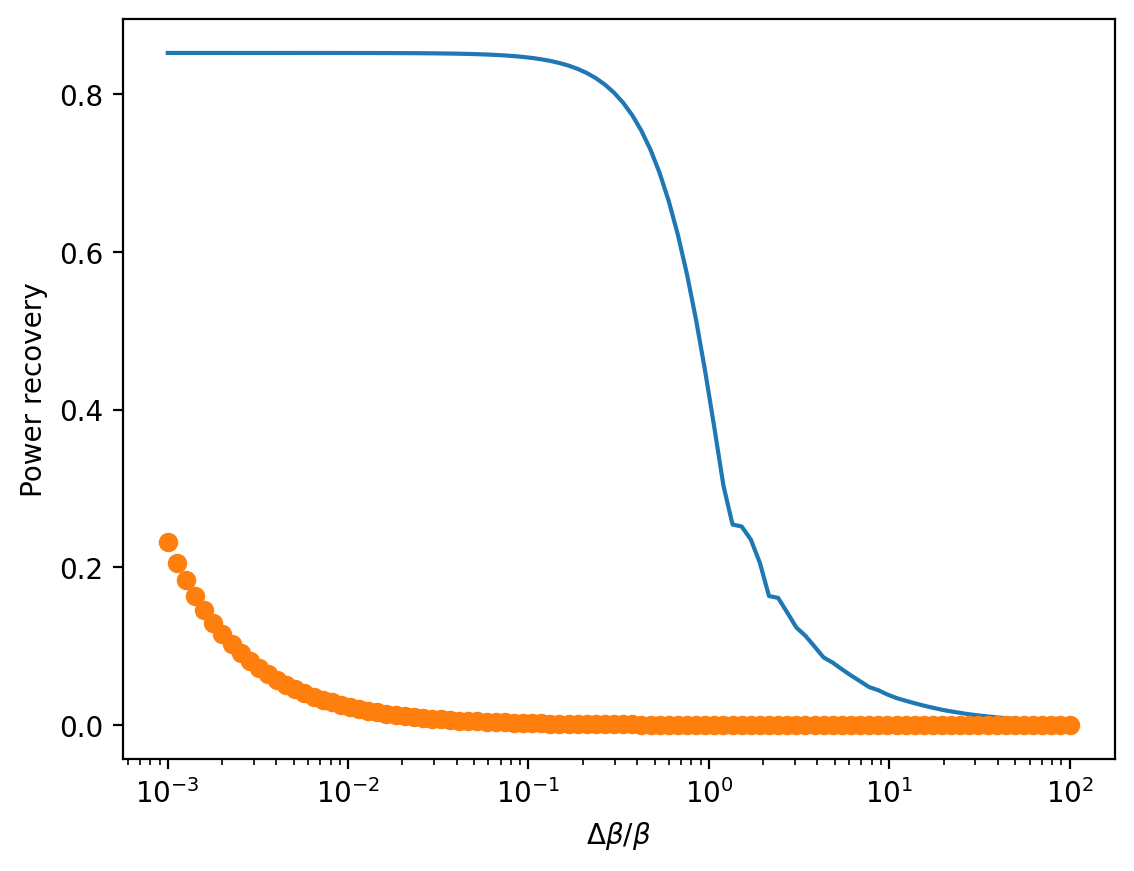

In [106]:
pl.semilogx(err_arr, power_arr)
pl.semilogx(err_arr, 1-analytical_arr, 'o')
pl.xlabel(r"$\Delta \beta / \beta$")
pl.ylabel("Power recovery")

## Comparison to cluster

In [51]:
cluster = np.loadtxt('results/f=20_M=1e-3_curve.txt')

Text(0, 0.5, 'Power recovered')

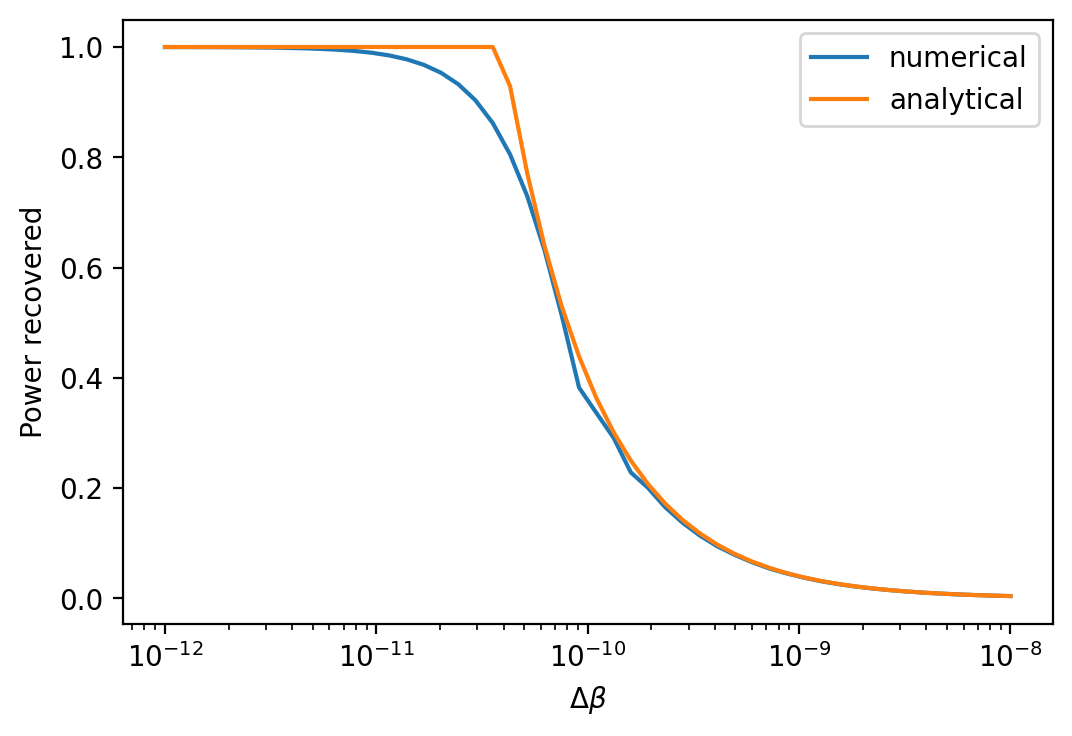

In [59]:
pl.semilogx(offset_arr, cluster, label='numerical')
pl.semilogx(offset_arr, 1-analytical_arr, label='analytical')
pl.legend()
pl.xlabel(r'$\Delta \beta$')
pl.ylabel("Power recovered")
# pl.title(r'$f_0 = 20, \, M_c = 10^{%.0f}M_\odot$' % np.log10(M))

## Calculating number of templates

In [104]:
f0 = 20
mass_space = np.logspace(-1, -2.5, 30)
beta_space = beta_calc(f0, mass_space)
offset_arr = np.logspace(-13, -9.5, 50)

In [105]:
scaling_30 = np.array([])
scaling_60 = np.array([])
scaling_90 = np.array([])

for m in mass_space:
    analytical_arr = analytical_loss(offset_arr, f0, m)
    scaling_30 = np.append(scaling_30, offset_arr[np.argmin(abs(1-analytical_arr-0.3))])
    scaling_60 = np.append(scaling_60, offset_arr[np.argmin(abs(1-analytical_arr-0.6))])
    scaling_90 = np.append(scaling_90, offset_arr[np.argmin(abs(1-analytical_arr-0.9))])

/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:15: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  from ipykernel import kernelapp as app


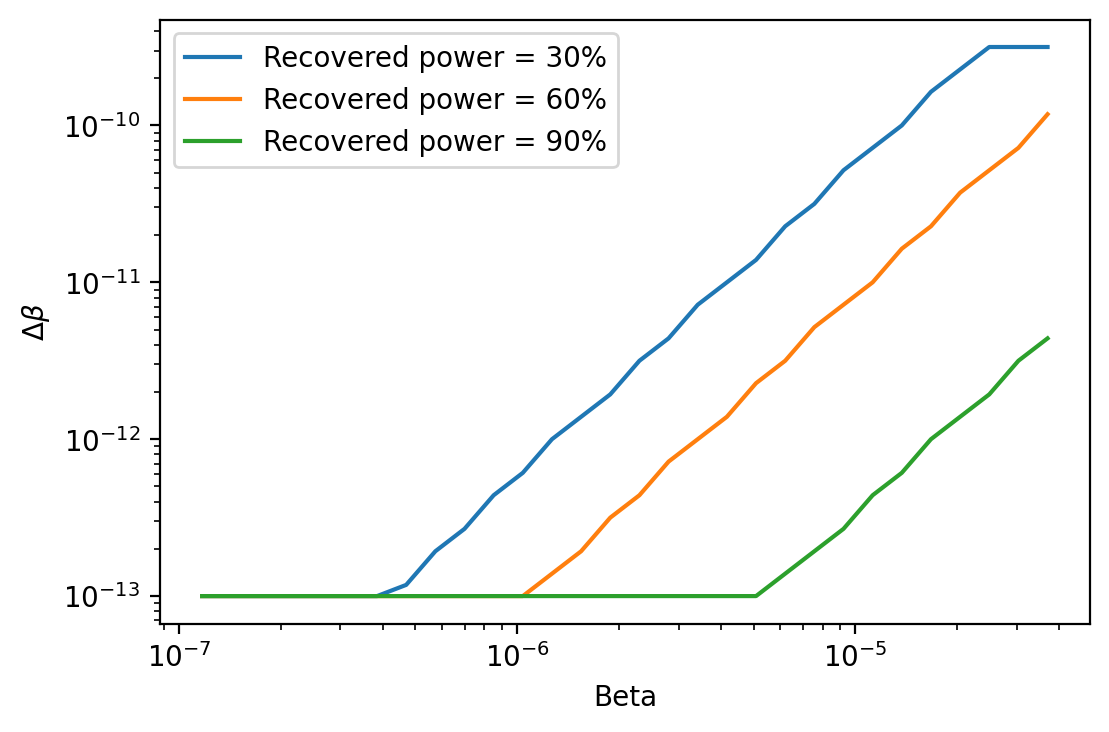

In [106]:
pl.loglog(beta_space, scaling_30, label='Recovered power = 30%')
pl.loglog(beta_space, scaling_60, label='Recovered power = 60%')
pl.loglog(beta_space, scaling_90, label='Recovered power = 90%')
# pl.axvline(beta_space[8], c='r', ls='--')
pl.xlabel("Beta")
pl.ylabel(r'$\Delta \beta$')
pl.legend()

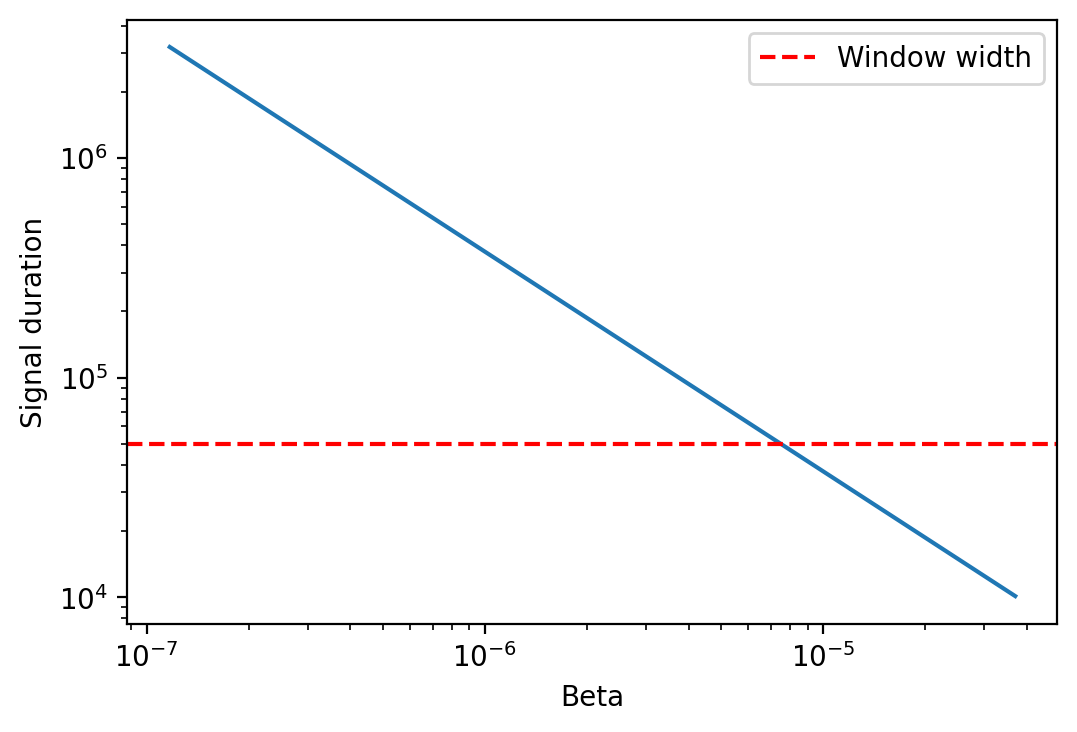

In [87]:
pl.loglog(beta_space, t_max_calc(f0, beta_space, 200))
pl.axhline(obs_duration, c='r', ls='--', label='Window width')
# pl.axvline(beta_space[8], c='r', ls='--')
pl.xlabel("Beta")
pl.ylabel(r'Signal duration')
pl.legend()

In [53]:
cross_idx = np.argmin(abs(t_max_calc(f0, beta_space, 200)-obs_duration))
np.log10(mass_space[cross_idx])

-1.4137931034482758